<a href="https://colab.research.google.com/github/anajuliayumibr/Analise-de-dados-02/blob/main/Aula_2%C2%B0SERS_Machine_CP02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Treinar Modelo

####Exercício
Treinar um modelo preditivo de classificação usando o algoritmo Regressão Logística (Logitic Regression no sklearn) para prever a estabilidade do grid (rede elétrica)

Atributo alvo (terget) -- COLUNA "STABF"

fonte de dados: https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data

###Preparação do ambiente

In [2]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Algortimo de regressão logistica
from sklearn.linear_model import LogisticRegression

#Separação de dados de treino e para teste
from sklearn.model_selection import train_test_split

#Métricas de avaliação para classificação
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import  confusion_matrix
from sklearn.metrics import classification_report  #serve para resumir tudo em uma tabela


###Carregando os dados e criando um dataframe

In [6]:
dados = pd.read_csv ("https://raw.githubusercontent.com/anajuliayumibr/Analise-de-dados-02/refs/heads/main/Data_for_UCI_named.csv")
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


###Análise Exploratória

In [9]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [12]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [11]:
#para atributos categoricos (colunas)
dados.describe(include="object")

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [10]:
#pra atributo numericos -- colunas numéricas
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [13]:
#Quais classes temos na coluna "stabf" (target)
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [15]:
#renomear as classes da coluna 'stabf'
dados['stabf'] = dados["stabf"].replace({"unstable": "Instável", 'stable': "Estável"})
dados['stabf'].head(10)


,stabf
0,Instável
1,Estável
2,Instável
3,Instável
4,Instável
5,Estável
6,Instável
7,Instável
8,Estável
9,Instável


In [16]:
#Quantos registros existem de cada classe 'Estável' e 'Instável'
dados['stabf'].value_counts()

#eh necessário verificar a diferença para que as amostras sejam próximas

,count
stabf,
Instável,6380
Estável,3620


###Separação dos dados de entrada (FEATURES) e dados de saída (TARGET)

In [17]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [18]:
#Dataframe X (maiúsculo) --> Features --> variáveis independentes
X = dados.drop(['stab', 'stabf'],axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [20]:
#Array y (minúsculo) ----> target ---> valor previsto pelo modelo ---> variável prevista pelo modelo
y = dados['stabf']
y.head()

,stabf
0,Instável
1,Estável
2,Instável
3,Instável
4,Instável


In [27]:
#separar os dados de treino e teste (usando a função 'train teste split)
#criar 4 variáveis                                   #define qnt % quer pra teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train.shape

(8000, 12)

In [31]:
X_test.shape

(2000, 12)

####Treinar, gerar as previsoes e treinar o modelo

In [32]:
#Instanciando o modelo
modelo = LogisticRegression()

In [33]:
#Treinamento do modelo
modelo.fit(X_train, y_train)

LogisticRegression()

In [34]:
#Gerando as previsões
y_predict = modelo.predict(X_test)
y_predict

array(['Instável', 'Instável', 'Instável', ..., 'Estável', 'Instável',
       'Instável'], dtype=object)

In [35]:
#Avaliaçao do modelo
accuracy = 100 * accuracy_score(y_test, y_predict)
print(f"Acurácia do modelo: {accuracy:.2f}%")

Acurácia do modelo: 81.70%


In [ ]:
#descobrir onde o modelo errou --> matriz de confusão usando matplotlib e seaborn
#pedir para Gemini criar usando essas biblioteas

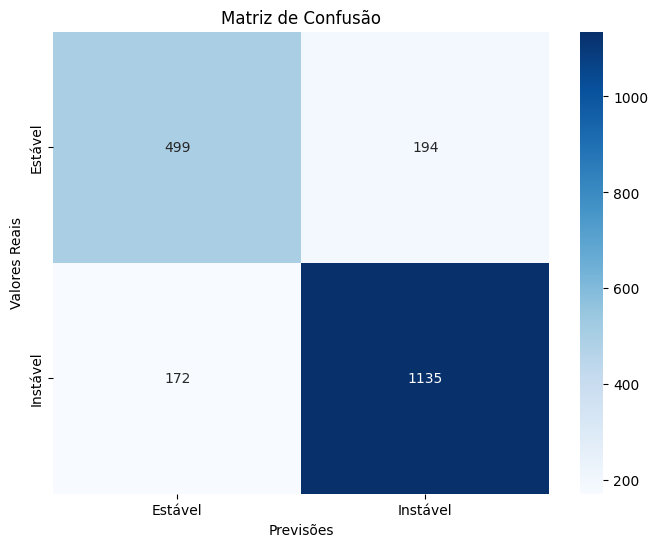

In [36]:
# Gerar a matriz de confusão
cm = confusion_matrix(y_test, y_predict)

# Criar o plot da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Estável', 'Instável'], yticklabels=['Estável', 'Instável'])
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()